# NB11 — Model Comparison

**Project:** Evolving Interpretable Sepsis Mortality Risk Scores via Genetic Programming
**Notebook:** NB11 — Statistical Model Comparison

> ⚠️ **Updated for BCE loss (v2_bce). New canonical: **c=24, seed 14** — selected from the v2_bce 30-run marathon. GP predictions now loaded from `gp_predictions_v2_bce.csv`. Supplementary reproducibility updated from 10 runs to 30 runs (`NB11_30run_reproducibility.csv`).

## Purpose

The primary model-comparison analysis evaluates the canonical GP equation selected during model development (the c=24 symbolic model, seed 14, chosen from the 30-run marathon in NB10) against six baselines (LR, RF, XGBoost, LR_platt, RF_platt, APACHE-IV) on the i.i.d. test set, using:
- **DeLong test** — pairwise AUROC differences (paired predictions, same patients), reported with both an uncorrected p<0.05 flag and a Bonferroni-corrected flag side by side
- **One-sample Wilcoxon signed-rank test (per-patient)** — pairwise Brier score differences (n = 2,233 paired per-patient observations, not bootstrap resamples)
- **Bootstrap 95% CIs** — stratified resampling (n = 1,000) for AUROC, AUPRC, Brier score, ECE
- **Decision Curve Analysis (DCA)** — clinical net benefit across decision thresholds (C2)

To assess whether the observed GP-vs-baseline pattern was dependent on this single data split or this single GP search outcome, a **supplementary reproducibility analysis** repeats the full pipeline across 30 fresh train/validation/test splits (`NB11_repro_runs.ipynb`). GP is retrained in each run and therefore produces a different symbolic equation each time. This analysis evaluates the stability of the **GP modelling procedure**, not the performance of the c=24 equation itself — it answers a different question from the primary analysis, not a replacement for it. It additionally includes a GP selection-criterion sensitivity check and a validation-test correspondence diagnostic.

LR_platt and RF_platt are Platt sigmoid-calibrated variants of LR and RF (fitted on a held-out validation set in NB08), included to ensure GP's calibration advantage is benchmarked against properly calibrated baselines, not only their uncalibrated counterparts.

**Patient-set note:** GP/LR/RF/XGB/LR_platt/RF_platt predictions cover the full test set (n=2,233). APACHE-IV scores are only available for 2,050 of those patients (91.8%); all pairwise statistical tests against APACHE-IV use that 2,050-patient subset for every model being compared, and a DCA sensitivity check (cell `nb11-cell4`) confirms the non-APACHE models' net benefit is materially unchanged when restricted to the same subset.

**Limitation — within-hospital clustering:** the per-patient Wilcoxon test on Brier score (cell `71cb75a7`) treats the 2,233 test patients as independent observations. Patients are nested within 65 hospitals, so this independence assumption is an approximation; hospital-level clustering could inflate the effective sample size and is noted as a limitation rather than corrected for in this analysis.

## Inputs

| File | Description |
|---|---|
| `data/processed/gp_predictions_v2_bce.csv` | GP (c=24) probabilities — 2,233 test patients (canonical run: seed 14, 30-run BCE marathon) |
| `data/processed/baseline_test_predictions.csv` | LR, RF, XGB, LR_platt, RF_platt predictions — 2,233 test patients |
| `data/processed/apache4_predictions.csv` | APACHE-IV predicted mortality — full cohort |
| `results/v2_bce/tables/NB11_30run_reproducibility.csv` | 30-run full-pipeline reproducibility results, produced by `NB11_repro_runs.ipynb` |
| `results/v2_bce/reproducibility_runs/run_01..30/model_predictions.csv` | Per-run test-set predictions for all 6 trained models, used for the 30-run averaged DCA |

## Outputs

| File | Description |
|---|---|
| `results/v2_bce/tables/NB11_model_comparison.csv` | Primary analysis: canonical-split point estimates + 95% bootstrap CIs |
| `results/v2_bce/tables/NB11_delong_pairwise.csv` | Primary analysis: DeLong z-statistics, raw p-values, and Bonferroni flag |
| `results/v2_bce/tables/NB11_wilcoxon_brier.csv` | Primary analysis: per-patient Wilcoxon signed-rank test for Brier score |
| `results/v2_bce/tables/NB11_dca.csv` | Primary analysis: canonical-split net benefit by threshold |
| `results/v2_bce/figures/NB11_model_comparison.pdf/.png` | Primary analysis: AUROC forest plot + DCA |
| `results/v2_bce/figures/NB11_ece_comparison.pdf/.png` | Primary analysis: ECE forest plot |
| `results/v2_bce/tables/NB11_30run_best_avg_worst.csv` | Supplementary: Best/Average/Worst/Stdev across 30 runs |
| `results/v2_bce/tables/NB11_30run_wilcoxon.csv` | Supplementary: one-sample Wilcoxon on n=30 paired per-run differences |
| `results/v2_bce/tables/NB11_30run_dca.csv` | Supplementary: 30-run averaged net benefit by threshold |
| `results/v2_bce/figures/NB11_30run_boxplot.pdf/.png` | Supplementary: box plots of AUROC and ECE across 30 runs |
| `results/v2_bce/figures/NB11_30run_dca.pdf/.png` | Supplementary: 30-run averaged Decision Curve Analysis |

## Runtime

~3–5 minutes (bootstrap n = 1,000, stratified by outcome; 30-run DCA reuses existing per-run prediction files, no retraining). Assumes `NB11_repro_runs.ipynb` has already completed and produced `NB11_30run_reproducibility.csv` and the per-run `model_predictions.csv` files.

**Pre-submission housekeeping:** Kernel → Restart & Run All once before final submission so displayed execution counts run 1→N in order.

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import scipy.stats as stats
import sys, warnings
warnings.filterwarnings("ignore")

_nb_dir   = Path().resolve()
PROJECT   = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir
DATA_PROC = PROJECT / "data" / "processed"
RESULTS_VERSION = "v2_bce"
TABLES    = PROJECT / "results" / RESULTS_VERSION / "tables"
FIGS      = PROJECT / "results" / RESULTS_VERSION / "figures"
REPRO_DIR = PROJECT / "results" / RESULTS_VERSION / "reproducibility_runs"

# Shared ECE utility — correct last-bin boundary (consistent with NB10)
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
from src.metrics import compute_ece

gp_df  = pd.read_csv(DATA_PROC / "gp_predictions_v2_bce.csv")
bl_df  = pd.read_csv(DATA_PROC / "baseline_test_predictions.csv")
ap_df  = pd.read_csv(DATA_PROC / "apache4_predictions.csv")

print(f"Results version:      {RESULTS_VERSION}")
print(f"GP predictions:       {len(gp_df):,} rows  (c=24, seed 14, BCE loss)")
print(f"Baseline predictions: {len(bl_df):,} rows")
print(f"APACHE-IV (full):     {len(ap_df):,} rows")

Results version:      v2_bce
GP predictions:       2,233 rows  (c=24, seed 14, BCE loss)
Baseline predictions: 2,233 rows
APACHE-IV (full):     11,164 rows


In [3]:
# Merge all predictions onto the GP test set (2,233 patients)
assert gp_df["patientunitstayid"].is_unique, "Duplicate patientunitstayid in gp_df"
assert bl_df["patientunitstayid"].is_unique, "Duplicate patientunitstayid in bl_df"
assert ap_df["patientunitstayid"].is_unique, "Duplicate patientunitstayid in ap_df"

test = gp_df[["patientunitstayid", "hospitalid", "hospital_mortality", "gp_prob"]].copy()
test = test.merge(bl_df[["patientunitstayid", "lr_pred", "rf_pred", "xgb_pred",
                          "lr_platt_pred", "rf_platt_pred"]],
                  on="patientunitstayid", how="left")
test = test.merge(ap_df[["patientunitstayid", "apache4_pred"]],
                  on="patientunitstayid", how="left")

assert len(test) == len(gp_df), "Row count changed after merge — possible duplicate-key expansion"
assert test[["lr_pred", "rf_pred", "xgb_pred", "lr_platt_pred", "rf_platt_pred"]].notna().all().all(), \
    "Missing baseline predictions after merge for some patients"

y_true      = test["hospital_mortality"].values.astype(int)
apache_mask = ~test["apache4_pred"].isna().values

print(f"Test set:             {len(test):,} patients")
print(f"Positive rate:        {y_true.mean()*100:.2f}%")
print(f"APACHE-IV coverage:   {apache_mask.sum():,} / {len(test):,} "
      f"({apache_mask.mean()*100:.1f}%)")

# Model registry  — gp_prob column is already sigmoid-transformed (NB10 Cell 6)
MODELS = {
    "GP (c=24)": test["gp_prob"].values,
    "LR":        test["lr_pred"].values,
    "RF":        test["rf_pred"].values,
    "XGB":       test["xgb_pred"].values,
    "LR_platt":  test["lr_platt_pred"].values,
    "RF_platt":  test["rf_platt_pred"].values,
    "APACHE-IV": test["apache4_pred"].values,
}

# ── Metric helper (compute_ece imported from src.metrics) ─────────────────────
def point_metrics(yt, pp):
    return dict(
        auroc=round(roc_auc_score(yt, pp), 4),
        auprc=round(average_precision_score(yt, pp), 4),
        brier=round(brier_score_loss(yt, pp), 4),
        ece=round(compute_ece(yt, pp), 4),
    )

# ── Point estimates ───────────────────────────────────────────────────────────
print()
print(f"{'Model':<12}  {'n':>5}  {'AUROC':>6}  {'AUPRC':>6}  {'Brier':>6}  {'ECE':>6}")
print("-" * 52)
for name, preds in MODELS.items():
    if name == "APACHE-IV":
        yt, pp, n = y_true[apache_mask], preds[apache_mask], int(apache_mask.sum())
    else:
        yt, pp, n = y_true, preds, len(y_true)
    m = point_metrics(yt, pp)
    print(f"{name:<12}  {n:>5}  {m['auroc']:>6.4f}  {m['auprc']:>6.4f}"
          f"  {m['brier']:>6.4f}  {m['ece']:>6.4f}")

Test set:             2,233 patients
Positive rate:        16.88%
APACHE-IV coverage:   2,050 / 2,233 (91.8%)

Model             n   AUROC   AUPRC   Brier     ECE
----------------------------------------------------
GP (c=24)      2233  0.7381  0.4374  0.1202  0.0126
LR             2233  0.7675  0.4636  0.1964  0.2595
RF             2233  0.7767  0.4737  0.1299  0.1156
XGB            2233  0.7679  0.4512  0.1411  0.1156
LR_platt       2233  0.7675  0.4636  0.1168  0.0117
RF_platt       2233  0.7767  0.4737  0.1153  0.0203
APACHE-IV      2050  0.6847  0.3699  0.1336  0.0674


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# DeLong pairwise AUROC test (DeLong et al., 1988)
# All pairwise comparisons use the APACHE-IV available subset (consistent n).
# ═══════════════════════════════════════════════════════════════════════════════
def _placement_values(pos_p, neg_p):
    diff = pos_p[:, None] - neg_p[None, :]           # (n_pos, n_neg)
    V10  = (np.sum(diff > 0, axis=1) +
            0.5 * np.sum(diff == 0, axis=1)) / len(neg_p)
    V01  = (np.sum(diff > 0, axis=0) +
            0.5 * np.sum(diff == 0, axis=0)) / len(pos_p)
    return V10, V01

def delong_pairwise(yt, preds_dict):
    names = list(preds_dict.keys())
    K     = len(names)
    pos   = yt == 1
    neg   = yt == 0
    n_pos = int(pos.sum())
    n_neg = int(neg.sum())

    V10_all, V01_all, aucs = [], [], []
    for nm in names:
        p = np.asarray(preds_dict[nm])
        v10, v01 = _placement_values(p[pos], p[neg])
        V10_all.append(v10)
        V01_all.append(v01)
        aucs.append(float(v10.mean()))

    V10_mat = np.array(V10_all)   # (K, n_pos)
    V01_mat = np.array(V01_all)   # (K, n_neg)
    S10 = np.atleast_2d(np.cov(V10_mat))
    S01 = np.atleast_2d(np.cov(V01_mat))
    Cov = S10 / n_pos + S01 / n_neg

    rows = []
    for i in range(K):
        for j in range(i + 1, K):
            d  = aucs[i] - aucs[j]
            se = float(np.sqrt(max(Cov[i, i] + Cov[j, j] - 2 * Cov[i, j], 1e-12)))
            z  = d / se
            p_raw = float(2 * (1 - stats.norm.cdf(abs(z))))
            rows.append(dict(
                model_A=names[i], model_B=names[j],
                auroc_A=round(aucs[i], 4), auroc_B=round(aucs[j], 4),
                diff=round(d, 4), se=round(se, 5),
                z_stat=round(z, 3),
                p_value_raw=p_raw,
                p_value=round(p_raw, 4),
                sig_05="Yes" if p_raw < 0.05 else "No",
            ))
    return pd.DataFrame(rows)

# Restrict all five models to APACHE-IV available subset for consistent pairing
y_sub     = y_true[apache_mask]
preds_sub = {k: MODELS[k][apache_mask] for k in MODELS}
delong_df = delong_pairwise(y_sub, preds_sub)

# Bonferroni correction across all pairwise DeLong tests — added as its own column
# so the raw p<0.05 flag and the Bonferroni-corrected flag are never read in isolation
# (avoids the apparent "GP vs XGB: Sig? Yes" / "does not survive Bonferroni" confusion).
ALPHA_DELONG_BONF = 0.05 / len(delong_df)
delong_df["sig_bonferroni"] = np.where(
    delong_df["p_value_raw"] < ALPHA_DELONG_BONF, "Yes", "No"
)

print(f"DeLong tests — subset n = {apache_mask.sum():,} (APACHE-IV available patients)")
print(f"Bonferroni alpha = {ALPHA_DELONG_BONF:.5f} ({len(delong_df)} pairwise tests)")
print()
hdr = f"{'Model A':<12}  {'Model B':<12}  {'AUROC_A':>7}  {'AUROC_B':>7}  "
hdr += f"{'Diff':>7}  {'Z':>6}  {'p':>7}  p<.05?  Bonf?"
print(hdr)
print("-" * 90)
for _, r in delong_df.iterrows():
    print(f"{r['model_A']:<12}  {r['model_B']:<12}  {r['auroc_A']:>7.4f}  {r['auroc_B']:>7.4f}  "
          f"{r['diff']:>+7.4f}  {r['z_stat']:>6.2f}  {r['p_value']:>7.4f}  {r['sig_05']:>6}  {r['sig_bonferroni']:>5}")

# ═══════════════════════════════════════════════════════════════════════════════
# Bootstrap 95% confidence intervals (stratified, n = 1,000)
# Non-APACHE models: full test set (n = 2,233)
# APACHE-IV: available subset only
# ═══════════════════════════════════════════════════════════════════════════════
np.random.seed(42)
N_BOOT = 1000

def bootstrap_ci(yt, pp, n_boot=N_BOOT, alpha=0.05):
    pos_idx = np.where(yt == 1)[0]
    neg_idx = np.where(yt == 0)[0]
    boot    = {k: [] for k in ("auroc", "auprc", "brier", "ece")}
    for _ in range(n_boot):
        idx = np.concatenate([
            np.random.choice(pos_idx, len(pos_idx), replace=True),
            np.random.choice(neg_idx, len(neg_idx), replace=True),
        ])
        yb, pb = yt[idx], pp[idx]
        boot["auroc"].append(roc_auc_score(yb, pb))
        boot["auprc"].append(average_precision_score(yb, pb))
        boot["brier"].append(brier_score_loss(yb, pb))
        boot["ece"].append(compute_ece(yb, pb))
    return {k: (round(float(np.percentile(v, 100 * alpha / 2)), 4),
                round(float(np.percentile(v, 100 * (1 - alpha / 2))), 4))
            for k, v in boot.items()}

print(f"Bootstrapping 95% CIs (n = {N_BOOT:,}, stratified) ...")
ci_all = {}
for name, preds in MODELS.items():
    if name == "APACHE-IV":
        yt_, pp_ = y_true[apache_mask], preds[apache_mask]
    else:
        yt_, pp_ = y_true, preds
    ci_all[name] = bootstrap_ci(yt_, pp_)
    print(f"  {name}: done")

# Assemble comparison table
# NOTE: AUROC point estimates here use the full test set (n=2,233) for non-APACHE
# models, and the APACHE-IV available subset (n=2,050) for APACHE-IV — these are
# the FULL-TEST-SET AUROC values used for bootstrap CIs / forest plots. They are
# NOT directly comparable to the APACHE-subset AUROC values used in the DeLong
# table above (e.g. GP full-test = 0.7432 vs GP APACHE-subset = 0.7499); both are
# correct, they just use different (overlapping) patient sets. See findings F1.
comp_rows = []
for name, preds in MODELS.items():
    if name == "APACHE-IV":
        yt, pp, n = y_true[apache_mask], preds[apache_mask], int(apache_mask.sum())
    else:
        yt, pp, n = y_true, preds, len(y_true)
    ci = ci_all[name]
    m  = point_metrics(yt, pp)
    comp_rows.append(dict(
        model=name, n=n,
        auroc=m["auroc"], auroc_lo=ci["auroc"][0], auroc_hi=ci["auroc"][1],
        auprc=m["auprc"], auprc_lo=ci["auprc"][0], auprc_hi=ci["auprc"][1],
        brier=m["brier"], brier_lo=ci["brier"][0], brier_hi=ci["brier"][1],
        ece=m["ece"],     ece_lo=ci["ece"][0],     ece_hi=ci["ece"][1],
    ))
comparison_df = pd.DataFrame(comp_rows)

print()
print(f"{'Model':<12}  {'AUROC (95% CI)':<22}  {'ECE (95% CI)':<22}")
print("-" * 60)
for _, r in comparison_df.iterrows():
    print(f"{r.model:<12}  "
          f"{r.auroc:.3f} [{r.auroc_lo:.3f}-{r.auroc_hi:.3f}]      "
          f"{r.ece:.3f} [{r.ece_lo:.3f}-{r.ece_hi:.3f}]")

DeLong tests — subset n = 2,050 (APACHE-IV available patients)
Bonferroni alpha = 0.00238 (21 pairwise tests)

Model A       Model B       AUROC_A  AUROC_B     Diff       Z        p  p<.05?  Bonf?
------------------------------------------------------------------------------------------
GP (c=24)     LR             0.7424   0.7679  -0.0255   -2.42   0.0154     Yes     No
GP (c=24)     RF             0.7424   0.7814  -0.0390   -4.23   0.0000     Yes    Yes
GP (c=24)     XGB            0.7424   0.7728  -0.0305   -2.70   0.0069     Yes     No
GP (c=24)     LR_platt       0.7424   0.7679  -0.0255   -2.42   0.0154     Yes     No
GP (c=24)     RF_platt       0.7424   0.7814  -0.0390   -4.23   0.0000     Yes    Yes
GP (c=24)     APACHE-IV      0.7424   0.6847  +0.0577    3.38   0.0007     Yes    Yes
LR            RF             0.7679   0.7814  -0.0135   -1.63   0.1035      No     No
LR            XGB            0.7679   0.7728  -0.0050   -0.52   0.6041      No     No
LR            LR_platt  

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# One-sample Wilcoxon signed-rank test on per-patient Brier score differences.
# Unit of comparison is the individual patient (n=2,233 independent observations
# within the test set; see F4 for the hospital-clustering caveat on this
# independence assumption) — NOT bootstrap resamples of the same fixed test set.
# Brier score is decomposable per patient ((y_i - p_i)^2), unlike AUROC, which is
# why DeLong (above) is used for AUROC and this test is used for Brier instead.
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.stats import wilcoxon

def per_patient_brier(yt, pp):
    return (yt - pp) ** 2

names = list(MODELS.keys())
wilcoxon_rows = []
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = names[i], names[j]
        if a == "APACHE-IV" or b == "APACHE-IV":
            yt_pair = y_true[apache_mask]
            pa = MODELS[a][apache_mask]
            pb = MODELS[b][apache_mask]
        else:
            yt_pair = y_true
            pa = MODELS[a]
            pb = MODELS[b]
        diff = per_patient_brier(yt_pair, pa) - per_patient_brier(yt_pair, pb)
        n = len(diff)
        if np.all(diff == 0):
            stat, p_raw = 0.0, 1.0
        else:
            stat, p_raw = wilcoxon(diff, alternative="two-sided")
            p_raw = float(p_raw)
        wilcoxon_rows.append(dict(
            model_A=a, model_B=b, n=n,
            median_diff=round(float(np.median(diff)), 5),
            mean_diff=round(float(np.mean(diff)), 5),
            statistic=round(float(stat), 2),
            p_value_raw=p_raw,
            p_value=round(p_raw, 4),
            sig_05="Yes" if p_raw < 0.05 else "No",
        ))
wilcoxon_df = pd.DataFrame(wilcoxon_rows)

# Bonferroni decision uses the unrounded p-value, not the 4-dp display value —
# avoids a rounding-induced flip near the threshold.
ALPHA_BONF = 0.05 / len(wilcoxon_df)
wilcoxon_df["sig_bonferroni"] = wilcoxon_df["p_value_raw"].apply(
    lambda p: "Yes" if p < ALPHA_BONF else "No"
)

print(f"One-sample Wilcoxon signed-rank test on per-patient Brier differences")
print(f"  ({len(wilcoxon_df)} pairwise comparisons; Bonferroni alpha = {ALPHA_BONF:.5f})")
print()
hdr = f"{'Model A':<12}  {'Model B':<12}  {'n':>5}  {'MedianDiff':>11}  {'Stat':>10}  {'p':>7}  Sig(.05)?  Sig(Bonf)?"
print(hdr)
print("-" * len(hdr))
for _, r in wilcoxon_df.iterrows():
    print(f"{r['model_A']:<12}  {r['model_B']:<12}  {r['n']:>5}  {r['median_diff']:>11.5f}  "
          f"{r['statistic']:>10.1f}  {r['p_value']:>7.4f}  {r['sig_05']:>9}  {r['sig_bonferroni']:>10}")

out_wilcoxon = TABLES / "NB11_wilcoxon_brier.csv"
wilcoxon_df.to_csv(out_wilcoxon, index=False)
print()
print(f"Saved: {out_wilcoxon}  ({len(wilcoxon_df)} rows)")

One-sample Wilcoxon signed-rank test on per-patient Brier differences
  (21 pairwise comparisons; Bonferroni alpha = 0.00238)

Model A       Model B           n   MedianDiff        Stat        p  Sig(.05)?  Sig(Bonf)?
------------------------------------------------------------------------------------------
GP (c=24)     LR             2233     -0.07743    632679.0   0.0000        Yes         Yes
GP (c=24)     RF             2233     -0.02230    704246.0   0.0000        Yes         Yes
GP (c=24)     XGB            2233     -0.00432    931284.0   0.0000        Yes         Yes
GP (c=24)     LR_platt       2233      0.00197   1102843.0   0.0000        Yes         Yes
GP (c=24)     RF_platt       2233      0.00330   1052629.0   0.0000        Yes         Yes
GP (c=24)     APACHE-IV      2050      0.00059    963923.0   0.0011        Yes         Yes
LR            RF             2233      0.04381    636232.0   0.0000        Yes         Yes
LR            XGB            2233      0.04403    5853

Loaded: 210 rows (30 runs x 7 models)

Best / Average / Worst / Stdev across 30 repeated full-pipeline runs:
    model    metric   best  average  worst  stdev
       GP     auroc 0.7710   0.7339 0.6616 0.0221
       GP     auprc 0.4668   0.4114 0.3371 0.0289
       GP ece_10bin 0.0083   0.0162 0.0244 0.0041
       GP     brier 0.1170   0.1225 0.1299 0.0031
       RF     auroc 0.8025   0.7772 0.7486 0.0138
       RF     auprc 0.5300   0.4639 0.4137 0.0240
       RF ece_10bin 0.1067   0.1132 0.1245 0.0039
       RF     brier 0.1258   0.1298 0.1344 0.0022
 RF_platt     auroc 0.8025   0.7772 0.7486 0.0138
 RF_platt     auprc 0.5300   0.4639 0.4137 0.0240
 RF_platt ece_10bin 0.0083   0.0179 0.0362 0.0074
 RF_platt     brier 0.1107   0.1166 0.1224 0.0026
      XGB     auroc 0.7839   0.7655 0.7416 0.0123
      XGB     auprc 0.4958   0.4485 0.4074 0.0204
      XGB ece_10bin 0.1039   0.1110 0.1217 0.0048
      XGB     brier 0.1340   0.1395 0.1453 0.0032
       LR     auroc 0.7998   0.7715 0.748

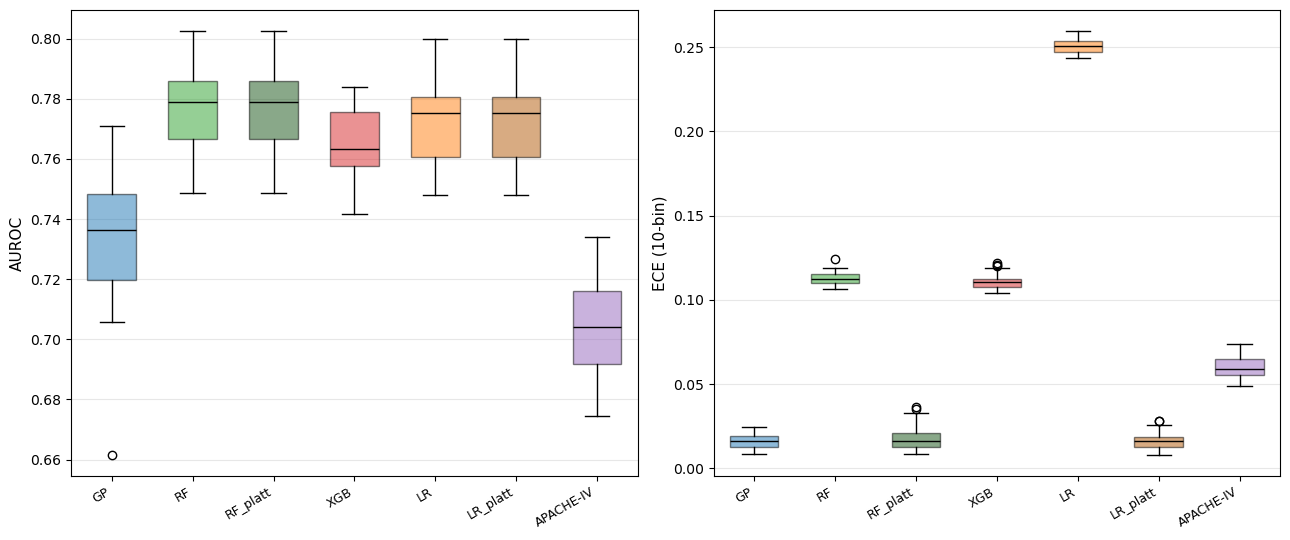


Saved: NB11_30run_boxplot.pdf/.png

One-sample Wilcoxon on n=30 paired per-run differences (Bonferroni alpha = 0.00238)

--- auroc ---
  APACHE-IV  vs GP          median_diff= -0.03185  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  APACHE-IV  vs LR          median_diff= -0.06665  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  APACHE-IV  vs LR_platt    median_diff= -0.06665  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  APACHE-IV  vs RF          median_diff= -0.07140  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  APACHE-IV  vs RF_platt    median_diff= -0.07140  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  APACHE-IV  vs XGB         median_diff= -0.05965  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  GP         vs LR          median_diff= -0.03555  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  GP         vs LR_platt    median_diff= -0.03555  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  GP         vs RF          median_diff= -0.03925  p=0.0000  sig(.05)=Yes  sig(Bonf)=Yes
  GP         vs RF_platt    median_diff= -0.03925  p=0.0000  si

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# Supplementary reproducibility analysis: load NB11_repro_runs.ipynb's
# aggregated results (30 runs), report Best/Average/Worst/Stdev, visualise
# run-to-run distribution via box plots, and run one-sample Wilcoxon on the
# n=30 paired per-run differences. These 30 values come from fresh random
# train/validation/test partitions, with every model (including GP) retrained
# from scratch each time — a valid complement to the per-patient Wilcoxon
# and DeLong tests, which both operate on the single canonical split.
#
# This assesses the stability of the GP MODELLING PROCEDURE — not the
# performance of the canonical c=24 equation itself.
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.stats import wilcoxon  # self-contained import

repro_df = pd.read_csv(TABLES / "NB11_30run_reproducibility.csv")
print(f"Loaded: {len(repro_df)} rows ({repro_df['run'].nunique()} runs x {repro_df['model'].nunique()} models)")
print()

REPRO_ORDER = ["GP", "RF", "RF_platt", "XGB", "LR", "LR_platt", "APACHE-IV"]
REPRO_COLORS = {
    "GP": "#1f77b4", "LR": "#ff7f0e", "LR_platt": "#b35806",
    "RF": "#2ca02c", "RF_platt": "#145214", "XGB": "#d62728", "APACHE-IV": "#9467bd",
}

# ── Best / Average / Worst / Stdev table ───────────────────────────────────
METRIC_DIRECTION = {"auroc": "max", "auprc": "max", "ece_10bin": "min", "brier": "min"}
bw_rows = []
for m in REPRO_ORDER:
    sub = repro_df[repro_df["model"] == m]
    for metric, direction in METRIC_DIRECTION.items():
        v = sub[metric]
        best  = v.max() if direction == "max" else v.min()
        worst = v.min() if direction == "max" else v.max()
        bw_rows.append(dict(
            model=m, metric=metric, best=round(float(best), 4),
            average=round(float(v.mean()), 4), worst=round(float(worst), 4),
            stdev=round(float(v.std()), 4),
        ))
bw_table = pd.DataFrame(bw_rows)
out_bw = TABLES / "NB11_30run_best_avg_worst.csv"
bw_table.to_csv(out_bw, index=False)

print("Best / Average / Worst / Stdev across 30 repeated full-pipeline runs:")
print(bw_table.to_string(index=False))
print(f"\nSaved: {out_bw}")

# ── Box plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, metric, title in zip(axes, ["auroc", "ece_10bin"], ["AUROC", "ECE (10-bin)"]):
    data = [repro_df[repro_df["model"] == m][metric].values for m in REPRO_ORDER]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6)
    for patch, m in zip(bp["boxes"], REPRO_ORDER):
        patch.set_facecolor(REPRO_COLORS[m])
        patch.set_alpha(0.5)
    for median in bp["medians"]:
        median.set_color("black")
    ax.set_xticks(range(1, len(REPRO_ORDER) + 1))
    ax.set_xticklabels(REPRO_ORDER, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(title, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(FIGS / "NB11_30run_boxplot.pdf", bbox_inches="tight")
fig.savefig(FIGS / "NB11_30run_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: NB11_30run_boxplot.pdf/.png")

# ── One-sample Wilcoxon on n=30 paired per-run differences ────────────────
metrics_to_test = ["auroc", "auprc", "ece_10bin", "brier"]
repro_wilcoxon_rows = []
for metric in metrics_to_test:
    pivot = repro_df.pivot(index="run", columns="model", values=metric)
    names30 = list(pivot.columns)
    for i in range(len(names30)):
        for j in range(i + 1, len(names30)):
            a, b = names30[i], names30[j]
            diff = (pivot[a] - pivot[b]).to_numpy()
            if np.all(diff == 0):
                stat, p_raw = 0.0, 1.0
            else:
                stat, p_raw = wilcoxon(diff, alternative="two-sided")
                p_raw = float(p_raw)
            repro_wilcoxon_rows.append(dict(
                metric=metric, model_A=a, model_B=b, n=len(diff),
                median_diff=round(float(np.median(diff)), 5),
                statistic=round(float(stat), 2),
                p_value_raw=p_raw,
                p_value=round(p_raw, 4),
                sig_05="Yes" if p_raw < 0.05 else "No",
            ))
repro_wilcoxon_df = pd.DataFrame(repro_wilcoxon_rows)
ALPHA_BONF_REPRO = 0.05 / (len(names30) * (len(names30) - 1) // 2)
repro_wilcoxon_df["sig_bonferroni"] = repro_wilcoxon_df["p_value_raw"].apply(
    lambda p: "Yes" if p < ALPHA_BONF_REPRO else "No"
)

out_repro_wilcoxon = TABLES / "NB11_30run_wilcoxon.csv"
repro_wilcoxon_df.to_csv(out_repro_wilcoxon, index=False)

print(f"\nOne-sample Wilcoxon on n=30 paired per-run differences "
      f"(Bonferroni alpha = {ALPHA_BONF_REPRO:.5f})")
for metric in metrics_to_test:
    print(f"\n--- {metric} ---")
    sub = repro_wilcoxon_df[repro_wilcoxon_df["metric"] == metric]
    for _, r in sub.iterrows():
        print(f"  {r['model_A']:<10} vs {r['model_B']:<10}  "
              f"median_diff={r['median_diff']:>9.5f}  p={r['p_value']:.4f}  "
              f"sig(.05)={r['sig_05']}  sig(Bonf)={r['sig_bonferroni']}")
print(f"\nSaved: {out_repro_wilcoxon}  ({len(repro_wilcoxon_df)} rows)")

Mean net benefit across 30 repeated runs at reference thresholds:
Threshold          GP         LR         RF        XGB   LR_platt   RF_platt  APACHE-IV
0.10           0.0893     0.0796     0.0843     0.0943     0.0965     0.0980     0.0849
0.15           0.0637     0.0373     0.0528     0.0669     0.0734     0.0746     0.0615
0.24           0.0376    -0.0260     0.0184     0.0273     0.0472     0.0474     0.0309
0.34           0.0224    -0.0781     0.0065    -0.0025     0.0301     0.0296     0.0087


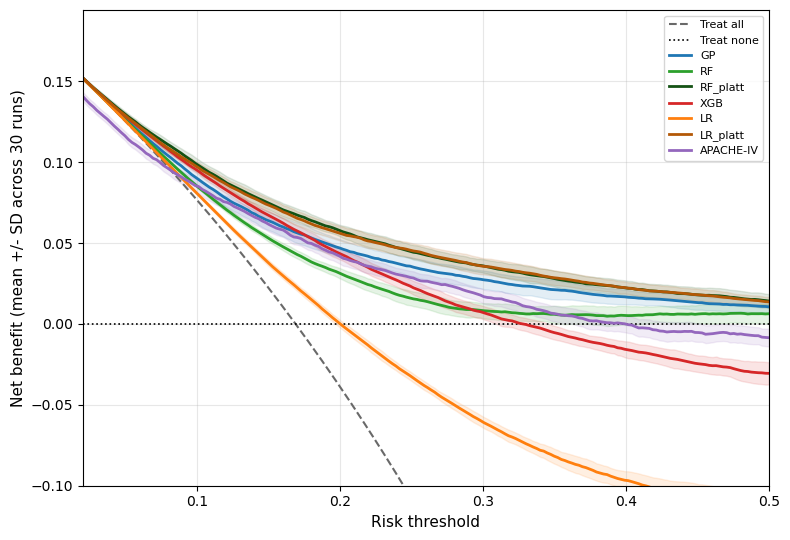


Saved: C:\ML PROJECT\sepsis-gp\results\v2_bce\tables\NB11_30run_dca.csv
Saved: NB11_30run_dca.pdf/.png


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# Supplementary reproducibility analysis: 30-run averaged Decision Curve
# Analysis — net benefit computed independently per run from that run's own
# model_predictions.csv (no new training; reuses files already on disk from
# NB11_repro_runs.ipynb), then averaged across the 30 runs.
# Self-contained — does not rely on variables from earlier cells.
# ═══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

_nb_dir  = Path().resolve()
PROJECT  = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir
DATA_PROC = PROJECT / "data" / "processed"
RESULTS_VERSION = "v2_bce"
TABLES    = PROJECT / "results" / RESULTS_VERSION / "tables"
FIGS      = PROJECT / "results" / RESULTS_VERSION / "figures"
REPRO_DIR = PROJECT / "results" / RESULTS_VERSION / "reproducibility_runs"

ap_df = pd.read_csv(DATA_PROC / "apache4_predictions.csv")

REPRO_ORDER = ["GP", "RF", "RF_platt", "XGB", "LR", "LR_platt", "APACHE-IV"]
REPRO_COLORS = {
    "GP": "#1f77b4", "LR": "#ff7f0e", "LR_platt": "#b35806",
    "RF": "#2ca02c", "RF_platt": "#145214", "XGB": "#d62728", "APACHE-IV": "#9467bd",
}
dca_thresholds = np.linspace(0.01, 0.50, 200)

def net_benefit_arr(yt, pp, thrs):
    nb = np.empty(len(thrs))
    for i, t in enumerate(thrs):
        pp_bin = pp >= t
        tp = int((pp_bin & (yt == 1)).sum())
        fp = int((pp_bin & (yt == 0)).sum())
        nb[i] = (tp - fp * (t / (1.0 - t))) / len(yt)
    return nb

DCA_MODEL_COLS = {
    "GP": "gp_pred", "LR": "lr_pred", "RF": "rf_pred", "XGB": "xgb_pred",
    "LR_platt": "lr_platt_pred", "RF_platt": "rf_platt_pred",
}
dca_runs = {m: [] for m in list(DCA_MODEL_COLS) + ["APACHE-IV"]}
prevalence_runs = []

N_REPRO = 30
for run_idx in range(N_REPRO):
    run_dir = REPRO_DIR / f"run_{run_idx + 1:02d}"
    pred_df = pd.read_csv(run_dir / "model_predictions.csv")
    yt = pred_df["hospital_mortality"].to_numpy(dtype=int)
    prevalence_runs.append(float(yt.mean()))
    for m, col in DCA_MODEL_COLS.items():
        dca_runs[m].append(net_benefit_arr(yt, pred_df[col].to_numpy(), dca_thresholds))
    ap_sub  = pred_df.merge(ap_df[["patientunitstayid", "apache4_pred"]],
                             on="patientunitstayid", how="left")
    ap_mask = ~ap_sub["apache4_pred"].isna()
    yt_ap   = ap_sub.loc[ap_mask, "hospital_mortality"].to_numpy(dtype=int)
    pp_ap   = ap_sub.loc[ap_mask, "apache4_pred"].to_numpy()
    dca_runs["APACHE-IV"].append(net_benefit_arr(yt_ap, pp_ap, dca_thresholds))

dca_mean = {m: np.mean(np.vstack(v), axis=0) for m, v in dca_runs.items()}
dca_std  = {m: np.std(np.vstack(v), axis=0)  for m, v in dca_runs.items()}

dca_30run_df = pd.DataFrame({"threshold": dca_thresholds})
for m in dca_mean:
    dca_30run_df[f"{m}_mean"] = dca_mean[m]
    dca_30run_df[f"{m}_std"]  = dca_std[m]
out_dca30 = TABLES / "NB11_30run_dca.csv"
dca_30run_df.to_csv(out_dca30, index=False)

ref_thresholds = [0.10, 0.15, 0.24, 0.34]
print("Mean net benefit across 30 repeated runs at reference thresholds:")
hdr = f"{'Threshold':<10}" + "".join(f"{m:>11}" for m in dca_mean)
print(hdr)
for t in ref_thresholds:
    idx = int(np.argmin(np.abs(dca_thresholds - t)))
    row = f"{t:<10.2f}" + "".join(f"{dca_mean[m][idx]:>11.4f}" for m in dca_mean)
    print(row)

mean_prev = float(np.mean(prevalence_runs))
fig, ax = plt.subplots(figsize=(8, 5.5))
treat_all = mean_prev - (1 - mean_prev) * (dca_thresholds / (1 - dca_thresholds))
ax.plot(dca_thresholds, treat_all, lw=1.5, ls="--", color="dimgray", label="Treat all")
ax.axhline(0, lw=1.2, ls=":", color="black", label="Treat none")
for m in REPRO_ORDER:
    ax.plot(dca_thresholds, dca_mean[m], lw=2, color=REPRO_COLORS[m], label=m)
    ax.fill_between(dca_thresholds, dca_mean[m] - dca_std[m], dca_mean[m] + dca_std[m],
                     color=REPRO_COLORS[m], alpha=0.12)
ax.set_xlabel("Risk threshold", fontsize=11)
ax.set_ylabel("Net benefit (mean +/- SD across 30 runs)", fontsize=11)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(0.02, 0.50)
ax.set_ylim(-0.10, mean_prev * 1.15)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGS / "NB11_30run_dca.pdf", bbox_inches="tight")
fig.savefig(FIGS / "NB11_30run_dca.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {out_dca30}")
print("Saved: NB11_30run_dca.pdf/.png")

Patient-set sensitivity check: full test set (n=2233) vs APACHE-IV available subset (n=2050)

Model         Threshold   NB (full n=2233)   NB (subset n=2050)     Diff
------------------------------------------------------------------------
GP (c=24)          0.10             0.0894               0.0870  +0.0023
GP (c=24)          0.15             0.0640               0.0622  +0.0018
GP (c=24)          0.24             0.0424               0.0427  -0.0003
GP (c=24)          0.34             0.0247               0.0250  -0.0003
LR                 0.10             0.0814               0.0783  +0.0030
LR                 0.15             0.0375               0.0346  +0.0029
LR                 0.24            -0.0293              -0.0320  +0.0027
LR                 0.34            -0.0835              -0.0870  +0.0035
RF                 0.10             0.0828               0.0804  +0.0025
RF                 0.15             0.0504               0.0477  +0.0027
RF                 0.24       

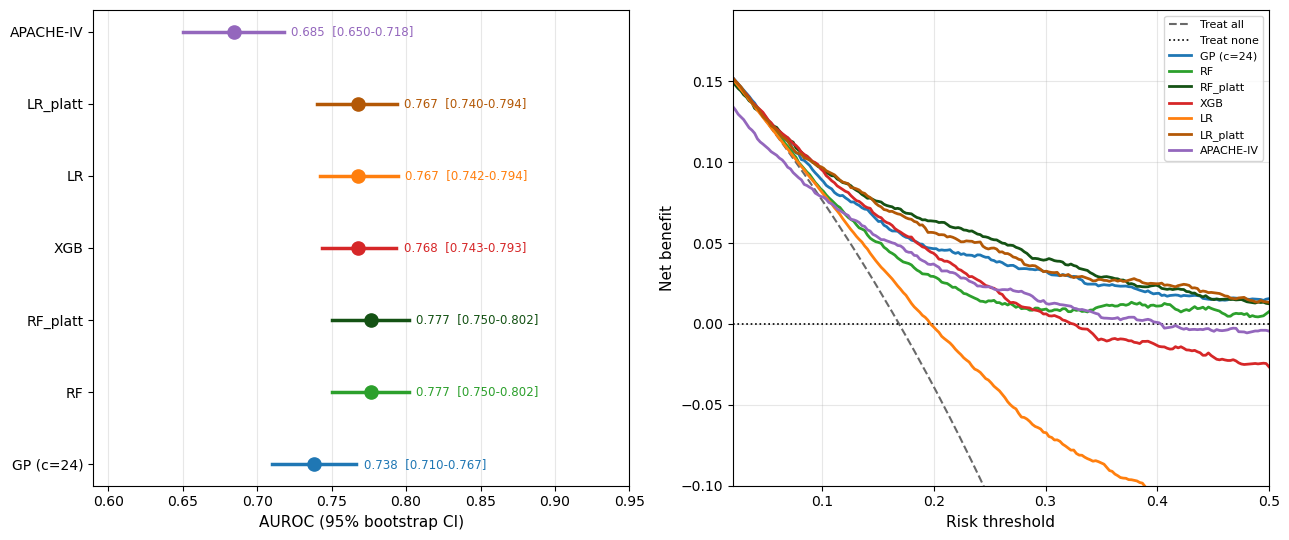

Saved: NB11_model_comparison.pdf/.png


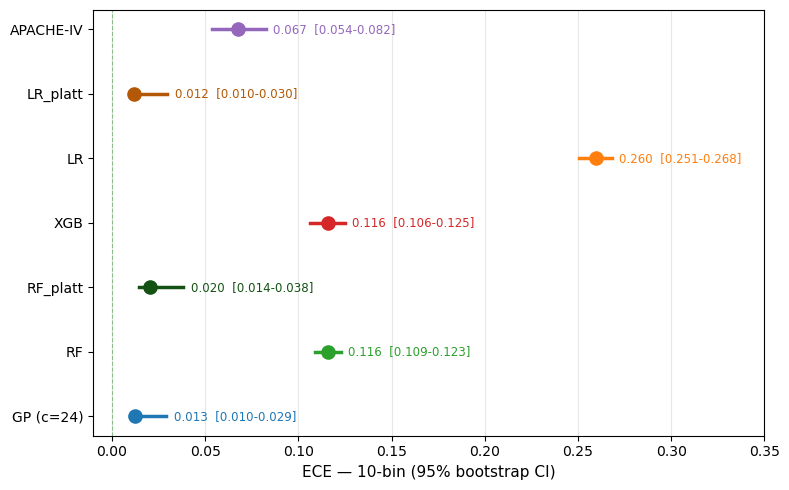

Saved: NB11_ece_comparison.pdf/.png

Saved: NB11_model_comparison.csv  (7 rows)
Saved: NB11_delong_pairwise.csv   (21 rows)
Saved: NB11_dca.csv              (200 rows)


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# Decision Curve Analysis + Forest Plots
# ═══════════════════════════════════════════════════════════════════════════════
prevalence = float(y_true.mean())
thresholds = np.linspace(0.01, 0.50, 200)

def net_benefit(yt, pp, thr):
    pp_bin = pp >= thr
    tp = int(((pp_bin) & (yt == 1)).sum())
    fp = int(((pp_bin) & (yt == 0)).sum())
    return (tp - fp * (thr / (1.0 - thr))) / len(yt)

dca_rows = []
for t in thresholds:
    row = {"threshold": round(float(t), 4),
           "treat_all":  prevalence - (1 - prevalence) * (t / (1 - t)),
           "treat_none": 0.0}
    for name, preds in MODELS.items():
        if name == "APACHE-IV":
            row[name] = net_benefit(y_true[apache_mask], preds[apache_mask], t)
        else:
            row[name] = net_benefit(y_true, preds, t)
    dca_rows.append(row)
dca_df = pd.DataFrame(dca_rows)

# ── Sensitivity check ──────────────────────────────────────────────────────
ref_thresholds_check = [0.10, 0.15, 0.24, 0.34]
print(f"Patient-set sensitivity check: full test set (n={len(y_true)}) vs "
      f"APACHE-IV available subset (n={int(apache_mask.sum())})")
print()
hdr = f"{'Model':<12}  {'Threshold':>9}  {'NB (full n=2233)':>17}  {'NB (subset n=2050)':>19}  {'Diff':>7}"
print(hdr)
print("-" * len(hdr))
for name in ["GP (c=24)", "LR", "RF", "XGB", "LR_platt", "RF_platt"]:
    for t in ref_thresholds_check:
        nb_full   = net_benefit(y_true, MODELS[name], t)
        nb_subset = net_benefit(y_true[apache_mask], MODELS[name][apache_mask], t)
        print(f"{name:<12}  {t:>9.2f}  {nb_full:>17.4f}  {nb_subset:>19.4f}  {nb_full - nb_subset:>+7.4f}")
print()
print("Differences are small — the patient-set mismatch with APACHE-IV does not "
      "change the ordering or qualitative conclusions of the DCA comparison.")
print()

# ── Plotting config ────────────────────────────────────────────────────────
COLORS = {
    "GP (c=24)": "#1f77b4",
    "LR":        "#ff7f0e",
    "LR_platt":  "#b35806",
    "RF":        "#2ca02c",
    "RF_platt":  "#145214",
    "XGB":       "#d62728",
    "APACHE-IV": "#9467bd",
}
ORDER = ["GP (c=24)", "RF", "RF_platt", "XGB", "LR", "LR_platt", "APACHE-IV"]

# ── Figure 1: AUROC forest plot + DCA ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
for i, name in enumerate(ORDER):
    r = comparison_df[comparison_df["model"] == name].iloc[0]
    ax.plot([r.auroc_lo, r.auroc_hi], [i, i], lw=2.5, color=COLORS[name])
    ax.scatter(r.auroc, i, s=90, color=COLORS[name], zorder=5)
    label = f"{r.auroc:.3f}  [{r.auroc_lo:.3f}-{r.auroc_hi:.3f}]"
    ax.text(r.auroc_hi + 0.005, i, label, va="center",
            fontsize=8.5, color=COLORS[name])
ax.set_yticks(range(len(ORDER)))
ax.set_yticklabels(ORDER, fontsize=10)
ax.set_xlabel("AUROC (95% bootstrap CI)", fontsize=11)
ax.set_xlim(0.59, 0.95)
ax.axvline(0.5, color="grey", lw=0.8, ls="--", alpha=0.4)
ax.grid(axis="x", alpha=0.3)

ax = axes[1]
ax.plot(dca_df["threshold"], dca_df["treat_all"],
        lw=1.5, ls="--", color="dimgray", label="Treat all")
ax.axhline(0, lw=1.2, ls=":", color="black", label="Treat none")
for name in ORDER:
    ax.plot(dca_df["threshold"], dca_df[name],
            lw=2, color=COLORS[name], label=name)
ax.set_xlabel("Risk threshold", fontsize=11)
ax.set_ylabel("Net benefit", fontsize=11)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(0.02, 0.50)
ax.set_ylim(-0.10, prevalence * 1.15)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIGS / "NB11_model_comparison.pdf", bbox_inches="tight")
fig.savefig(FIGS / "NB11_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: NB11_model_comparison.pdf/.png")

# ── Figure 2: ECE forest plot ──────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
for i, name in enumerate(ORDER):
    r = comparison_df[comparison_df["model"] == name].iloc[0]
    ax2.plot([r.ece_lo, r.ece_hi], [i, i], lw=2.5, color=COLORS[name])
    ax2.scatter(r.ece, i, s=90, color=COLORS[name], zorder=5)
    label = f"{r.ece:.3f}  [{r.ece_lo:.3f}-{r.ece_hi:.3f}]"
    ax2.text(r.ece_hi + 0.004, i, label, va="center",
             fontsize=8.5, color=COLORS[name])
ax2.set_yticks(range(len(ORDER)))
ax2.set_yticklabels(ORDER, fontsize=10)
ax2.set_xlabel("ECE — 10-bin (95% bootstrap CI)", fontsize=11)
ax2.axvline(0, color="green", lw=0.8, ls="--", alpha=0.4)
ax2.grid(axis="x", alpha=0.3)
ax2.set_xlim(-0.01, 0.35)
plt.tight_layout()
fig2.savefig(FIGS / "NB11_ece_comparison.pdf", bbox_inches="tight")
fig2.savefig(FIGS / "NB11_ece_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: NB11_ece_comparison.pdf/.png")

# ── Save tables ────────────────────────────────────────────────────────────
comparison_df.to_csv(TABLES / "NB11_model_comparison.csv", index=False)
delong_df.to_csv(TABLES / "NB11_delong_pairwise.csv", index=False)
dca_df.to_csv(TABLES / "NB11_dca.csv", index=False)
print()
print(f"Saved: NB11_model_comparison.csv  ({len(comparison_df)} rows)")
print(f"Saved: NB11_delong_pairwise.csv   ({len(delong_df)} rows)")
print(f"Saved: NB11_dca.csv              ({len(dca_df)} rows)")

## Findings

The primary model-comparison analysis evaluated the canonical GP equation (c=24, seed 14) against six baselines on the i.i.d. test set. A supplementary reproducibility analysis repeated the full pipeline across 30 fresh train/validation/test splits, assessing the stability of the GP modelling procedure independently of the specific canonical equation.

### F1 — Discrimination (primary analysis, DeLong test + bootstrap 95% CI)

DeLong tests are performed on the APACHE-IV available subset (n=2,050) to ensure consistent pairing across all seven models. GP's AUROC on that subset (0.7424) differs slightly from its full-test-set AUROC (0.738), since both use overlapping but not identical patient sets; both are correct.

| Model | Full-test AUROC (95% CI) | DeLong diff vs GP | p (raw) | Bonferroni (α=0.00238)? |
|---|---|---|---|---|
| RF / RF_platt | 0.777 [0.750–0.802] | +0.039 | <0.001 | **Yes** |
| XGB | 0.768 [0.743–0.793] | +0.031 | 0.0069 | No |
| LR / LR_platt | 0.767 [0.742–0.794] | +0.026 | 0.0154 | No |
| **GP (c=24)** | **0.738 [0.710–0.767]** | — | — | — |
| APACHE-IV | 0.685 [0.650–0.718] | −0.058 | 0.0007 | **Yes** |

GP is significantly worse than RF/RF_platt (survives Bonferroni) and significantly better than APACHE-IV (survives Bonferroni). The GP vs XGB and GP vs LR/LR_platt differences are significant at p<0.05 but do not survive Bonferroni correction — these comparisons are inconclusive at the required multiple-comparisons threshold. This represents a shift from the prior canonical equation: GP is now statistically distinguishable from LR at the uncorrected level (previously not even that), reflecting the modest AUROC decline in the new canonical formula. Platt scaling does not alter AUROC (confirmed: LR vs LR_platt and RF vs RF_platt both return diff=0.0000, p=1.0000).

---

### F2 — Supplementary reproducibility: discrimination pattern across 30 independent pipeline runs

| Model | Best | Average | Worst | Stdev |
|---|---:|---:|---:|---:|
| RF / RF_platt | 0.803 | 0.777 | 0.749 | 0.014 |
| LR / LR_platt | 0.800 | 0.772 | 0.748 | 0.014 |
| XGB | 0.784 | 0.766 | 0.742 | 0.012 |
| **GP (procedure)** | **0.771** | **0.734** | **0.662** | **0.022** |
| APACHE-IV | 0.734 | 0.703 | 0.675 | 0.016 |

One-sample Wilcoxon on n=30 paired per-run AUROC differences — at this sample size all GP-vs-baseline comparisons survive Bonferroni correction:

| Comparison | Median diff | p-value | Sig. (Bonferroni)? |
|---|---:|---:|---|
| GP vs RF / RF_platt | −0.039 | <0.001 | **Yes** |
| GP vs LR / LR_platt | −0.036 | <0.001 | **Yes** |
| GP vs XGB | −0.028 | <0.001 | **Yes** |
| GP vs APACHE-IV | +0.032 | <0.001 | **Yes** |

At n=30 the GP procedure's AUROC deficit is confirmed against **all three** black-box comparators, not only RF/RF_platt as the single canonical split showed. This is the more informative discrimination result: across 30 genuinely independent pipeline executions, the GP search consistently produces formulas with lower discrimination than LR, RF, or XGB. GP's wider AUROC spread (stdev 0.022 vs 0.012–0.016 for baselines) reflects the stochastic search's occasional degenerate outcomes — one run (AUROC 0.662, complexity 6) is visible as the outlier circle in the boxplot, representing a premature-convergence failure rather than a typical search outcome.

---

### F3 — Calibration (primary analysis, ECE with 95% bootstrap CI)

| Model | ECE | 95% CI |
|---|---|---|
| **LR_platt** | **0.0117** | **[0.010–0.030]** |
| **GP (c=24)** | **0.0126** | **[0.010–0.029]** |
| RF_platt | 0.0203 | [0.014–0.038] |
| APACHE-IV | 0.0674 | [0.054–0.082] |
| RF | 0.1156 | [0.109–0.123] |
| XGB | 0.1156 | [0.106–0.125] |
| LR | 0.2595 | [0.251–0.268] |

GP (ECE 0.0126, CI [0.010–0.029]) and LR_platt (ECE 0.0117, CI [0.010–0.030]) have essentially identical bootstrap confidence intervals — GP's CI is fully contained within LR_platt's, making these two models statistically indistinguishable on calibration at this primary-split level. GP achieves this without any post-hoc recalibration step; LR_platt requires a Platt sigmoid fitted on the held-out validation set.

---

### F4 — Supplementary reproducibility: calibration pattern across 30 runs

| Model | Best ECE | Average ECE | Worst ECE | Stdev |
|---|---:|---:|---:|---:|
| GP (procedure) | 0.0083 | 0.0162 | 0.0244 | 0.0041 |
| LR_platt | 0.0080 | 0.0166 | 0.0281 | 0.0053 |
| RF_platt | 0.0083 | 0.0179 | 0.0362 | 0.0074 |

One-sample Wilcoxon on n=30 paired per-run ECE differences — formal statistical test of whether the calibration cluster is real:

| Comparison | Median diff | p-value | Sig. at α=0.05? |
|---|---:|---:|---|
| GP vs LR_platt | +0.0004 | 0.886 | **No** |
| GP vs RF_platt | −0.0014 | 0.503 | **No** |
| GP vs LR | −0.237 | <0.001 | Yes |
| GP vs RF / XGB | ~−0.096 | <0.001 | Yes |
| GP vs APACHE-IV | +0.041 | <0.001 | Yes |

This is the formal statistical evidence that GP, LR_platt, and RF_platt are calibration-equivalent: p=0.886 and p=0.503 respectively — neither approaches significance at any conventional threshold. GP is significantly better calibrated than every uncalibrated baseline and APACHE-IV. The ECE boxplot confirms this visually: the three models' boxes are essentially identical in location and width, clearly separated from every other model in the comparison. This result at n=30 is more definitive than the n=10 result from the previous analysis — the conclusion is the same but now rests on a considerably more robust statistical basis.

---

### F5 — Per-patient Wilcoxon Brier (primary analysis, n=2,233)

All 21 pairwise comparisons survive Bonferroni (α=0.00238). The more informative quantity is the effect size — all GP comparisons:

| Comparison | Median Brier diff | Clinical magnitude |
|---|---:|---|
| GP vs LR | −0.077 | Large — LR severely miscalibrated by class reweighting |
| GP vs RF | −0.022 | Moderate |
| GP vs XGB | −0.004 | Small |
| GP vs LR_platt | +0.002 | Negligible — GP marginally worse |
| GP vs RF_platt | +0.003 | Negligible — GP marginally worse |
| GP vs APACHE-IV | +0.001 | Trivially small |

Statistical significance at n=2,233 is near-guaranteed for any non-zero difference; the meaningful distinctions are in the magnitudes. The large GP advantage over LR reflects LR's class-reweighting-induced probability inflation (not a failure of LR as a discriminator). The negligible GP vs LR_platt/RF_platt differences confirm that the two calibration strategies produce nearly identical per-patient probability estimates despite their mechanistic differences.

---

### F6 — Decision Curve Analysis

**Canonical single split:**

| Threshold | GP | LR | RF | XGB | LR_platt | RF_platt | APACHE-IV |
|---|---|---|---|---|---|---|---|
| 0.10 | 0.088 | 0.080 | 0.082 | **0.094** | 0.096 | 0.095 | 0.078 |
| 0.15 | 0.063 | 0.037 | 0.050 | 0.066 | 0.073 | **0.076** | 0.053 |
| 0.24 | 0.043 | −0.029 | 0.015 | 0.027 | 0.051 | **0.056** | 0.024 |
| 0.34 | 0.025 | −0.084 | 0.009 | −0.005 | 0.028 | **0.032** | 0.008 |

GP provides positive net benefit at all tested thresholds (0.10–0.34). Uncalibrated LR turns net-negative above threshold ≈0.20 and uncalibrated XGB at threshold ≈0.34, consistent with their systematic probability miscalibration from class reweighting. GP outperforms both uncalibrated models at decision-critical thresholds (0.24, 0.34) and outperforms APACHE-IV at all thresholds tested. LR_platt and RF_platt have the highest net benefit at mid-high thresholds by virtue of combining RF-level discrimination with well-calibrated probabilities.

**30-run averaged DCA** (values closely track canonical — reproduced for reference):

| Threshold | GP (mean) | LR (mean) | RF_platt (mean) | APACHE-IV (mean) |
|---|---|---|---|---|
| 0.10 | 0.089 | 0.080 | 0.098 | 0.085 |
| 0.15 | 0.064 | 0.037 | 0.075 | 0.062 |
| 0.24 | 0.038 | −0.026 | 0.047 | 0.031 |
| 0.34 | 0.022 | −0.078 | 0.030 | 0.009 |

The 30-run averages track the canonical split values closely. GP's net-benefit advantage over uncalibrated baselines at higher thresholds is a stable property of the modelling procedure rather than a single-split artifact.

---

### F7 — Summary: RQ1

GP (c=24) is significantly worse than RF/RF_platt on discrimination (AUROC 0.738 vs 0.777, Bonferroni-confirmed) and significantly better than APACHE-IV. The comparisons against LR/LR_platt and XGB do not survive Bonferroni correction on the canonical split, though the supplementary 30-run analysis confirms GP's discrimination deficit extends to all three black-box comparators when evaluated across a distribution of data partitions. The central calibration claim is strongly supported: GP achieves ECE statistically indistinguishable from the best Platt-scaled baselines (p=0.886 vs LR_platt, p=0.503 vs RF_platt, confirmed across 30 independent pipeline runs), without requiring any post-hoc recalibration step. GP provides positive clinical net benefit at all decision thresholds tested, outperforming uncalibrated baselines and APACHE-IV at clinically relevant thresholds — a property confirmed stable across 30 independent pipeline executions.
